# HATR con feature nominali — River vs CapyMOA

Dataset sintetico con 3 feature nominali (`season`, `weather`, `time_of_day`) e 2 numeriche (`temperature`, `humidity`), con concept drift abrupt a metà stream: le feature nominali rilevanti cambiano da `season` a `time_of_day`.

Configurazione fissa: `leaf_prediction='mean'`, `bootstrap_sampling=False`.

## Setup

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import jpype
import jpype.config
jpype.config.destroy_jvm = False

HATR_JAR = os.path.normpath(os.path.join(os.getcwd(), '..', 'implementation',
    'hatr-moa', 'target',
    'hoeffding-adaptive-tree-regressor-moa-1.0-SNAPSHOT.jar'))
assert os.path.exists(HATR_JAR), (
    f"JAR non trovato: {HATR_JAR}\n"
    "compilare: cd implementation/hatr-moa && mvn -o package -DskipTests")

if jpype.isJVMStarted():
    print('JVM già avviata — Kernel -> Restart & Run All')
else:
    os.environ["CAPYMOA_JVM_ARGS"] = "-Xmx8g -Xss10M -XX:ErrorFile=/dev/null"
    jpype.addClassPath(HATR_JAR)

sys.path.insert(0, os.path.normpath(os.path.join(os.getcwd(), '..', 'implementation')))

from capymoa.stream import Schema
from capymoa.instance import RegressionInstance
from river import tree as river_tree, drift as river_drift, preprocessing as river_prep
from hatr_capymoa import HoeffdingAdaptiveTreeRegressor as CapyHATR

print("Setup OK")

Setup OK


## Dataset sintetico con feature nominali e concept drift

In [2]:
N        = 20_000
DRIFT_AT = 10_000
rng      = np.random.RandomState(42)

SEASON_VALS  = ['spring', 'summer', 'autumn', 'winter']
WEATHER_VALS = ['sunny', 'cloudy', 'rainy']
TIME_VALS    = ['morning', 'afternoon', 'evening', 'night']

season_idx  = rng.randint(0, 4, N)
weather_idx = rng.randint(0, 3, N)
time_idx    = rng.randint(0, 4, N)

temperature = rng.uniform(-5.0, 35.0, N)
humidity    = rng.uniform(20.0, 90.0, N)
noise       = 0.4 * rng.randn(N)

# Pre-drift: season e temperature determinano il consumo energetico
SEASON_EFF = np.array([1.0, -2.0, 0.5, 4.0])   # spring, summer, autumn, winter
y_pre = (SEASON_EFF[season_idx]
         - 0.08 * temperature
         + 0.5 * (weather_idx == 2)              # rainy +0.5
         + noise)

# Post-drift: time_of_day e humidity diventano le feature dominanti
TIME_EFF = np.array([2.0, 0.5, 3.5, 0.2])        # morning, afternoon, evening, night
y_post = (TIME_EFF[time_idx]
          + 0.04 * humidity
          + noise)

y = np.where(np.arange(N) < DRIFT_AT, y_pre, y_post)

print(f"Dataset: N={N}, drift_at={DRIFT_AT}")
print(f"  Pre-drift  y ∈ [{y_pre.min():.2f}, {y_pre.max():.2f}]")
print(f"  Post-drift y ∈ [{y_post.min():.2f}, {y_post.max():.2f}]")
print(f"  Nominali: season({len(SEASON_VALS)}), weather({len(WEATHER_VALS)}), time_of_day({len(TIME_VALS)})")

Dataset: N=20000, drift_at=10000
  Pre-drift  y ∈ [-5.96, 5.74]
  Post-drift y ∈ [-0.16, 8.25]
  Nominali: season(4), weather(3), time_of_day(4)


## Schema CapyMOA

In [3]:
SCHEMA = Schema.from_custom(
    features=['season', 'weather', 'time_of_day', 'temperature', 'humidity', 'target'],
    target='target',
    categories={
        'season':      SEASON_VALS,
        'weather':     WEATHER_VALS,
        'time_of_day': TIME_VALS,
    },
    name='nominal_drift'
)
print(SCHEMA)

@relation nominal_drift

@attribute season {spring,summer,autumn,winter}
@attribute weather {sunny,cloudy,rainy}
@attribute time_of_day {morning,afternoon,evening,night}
@attribute temperature numeric
@attribute humidity numeric
@attribute target numeric

@data


## Parametri e funzione di valutazione

In [4]:
BASE = dict(
    grace_period=200, delta=1e-7, tau=0.05,
    model_selector_decay=0.95, drift_window_threshold=300,
    switch_significance=0.05, min_samples_split=5,
    adwin_delta=0.002, learning_ratio=0.01, seed=0
)

# configurazione fissa: deterministica, no bootstrap
CFG = dict(leaf_prediction='mean', bootstrap_sampling=False)

In [5]:
def build_river(cfg, base):
    return river_tree.HoeffdingAdaptiveTreeRegressor(
        grace_period=base['grace_period'],
        delta=base['delta'],
        tau=base['tau'],
        leaf_prediction=cfg['leaf_prediction'],
        bootstrap_sampling=cfg['bootstrap_sampling'],
        model_selector_decay=base['model_selector_decay'],
        drift_window_threshold=base['drift_window_threshold'],
        switch_significance=base['switch_significance'],
        min_samples_split=base['min_samples_split'],
        drift_detector=river_drift.ADWIN(delta=base['adwin_delta'], clock=32),
        seed=base['seed'],
    )


def build_capy(cfg, schema, base):
    return CapyHATR(
        schema,
        grace_period=base['grace_period'],
        split_confidence=base['delta'],
        tie_threshold=base['tau'],
        leaf_prediction=cfg['leaf_prediction'],
        bootstrap_sampling=cfg['bootstrap_sampling'],
        model_selector_decay=base['model_selector_decay'],
        drift_window_threshold=base['drift_window_threshold'],
        switch_significance=base['switch_significance'],
        min_samples_split=base['min_samples_split'],
        adwin_delta=base['adwin_delta'],
        learning_ratio=base['learning_ratio'],
        random_seed=base['seed'],
    )


def eval_nominal(season_idx, weather_idx, time_idx, temperature, humidity, y,
                 framework, cfg, base, schema=None, scale=True):
    """
    Valutazione prequential su dataset con feature nominali.

    River riceve le feature nominali come stringhe (gestisce categorici nativamente).
    CapyMOA riceve gli indici interi (codifica ARFF standard).
    Lo scaler River StandardScaler si applica soltanto alle feature numeriche
    (ignora stringhe); per CapyMOA lo scaler viene applicato esplicitamente
    solo a temperature e humidity prima di comporre l'array.
    """
    n       = len(y)
    is_capy = (framework == 'capy')
    model   = build_capy(cfg, schema, base) if is_capy else build_river(cfg, base)
    scaler  = river_prep.StandardScaler() if scale else None
    preds   = np.empty(n)

    for i in range(n):
        num_dict = {'temperature': float(temperature[i]),
                    'humidity':    float(humidity[i])}
        if scaler:
            scaled_num = scaler.transform_one(num_dict)
        else:
            scaled_num = num_dict

        if is_capy:
            arr = np.array([
                float(season_idx[i]),
                float(weather_idx[i]),
                float(time_idx[i]),
                scaled_num['temperature'],
                scaled_num['humidity'],
            ])
            inst_p = RegressionInstance(schema, (arr, float(y[i])))
            preds[i] = model.predict(inst_p) or 0.0
            if scaler:
                scaler.learn_one(num_dict)
            inst_t = RegressionInstance(schema, (arr, float(y[i])))
            model.train(inst_t)
        else:
            x = {
                'season':      SEASON_VALS[season_idx[i]],
                'weather':     WEATHER_VALS[weather_idx[i]],
                'time_of_day': TIME_VALS[time_idx[i]],
                'temperature': scaled_num['temperature'],
                'humidity':    scaled_num['humidity'],
            }
            preds[i] = model.predict_one(x) or 0.0
            if scaler:
                scaler.learn_one(num_dict)
            model.learn_one(x, float(y[i]))

    return preds, model


def mae(yt, yp):  return float(np.mean(np.abs(yt - yp)))
def rmse(yt, yp): return float(np.sqrt(np.mean((yt - yp)**2)))
def r2(yt, yp):
    st = np.sum((yt - np.mean(yt))**2)
    return float(1 - np.sum((yt - yp)**2) / st) if st > 0 else 0.0
def win_mae(yt, yp, w=500):
    return np.convolve(np.abs(yt - yp), np.ones(w) / w, mode='valid')


print("Funzioni di valutazione definite")

Funzioni di valutazione definite


## Esecuzione

In [6]:
SKIP = 50  # ignora le prime predizioni a freddo

river_preds, river_model = eval_nominal(
    season_idx, weather_idx, time_idx, temperature, humidity, y,
    framework='river', cfg=CFG, base=BASE, scale=True
)
print("River: done")

capy_preds, capy_model = eval_nominal(
    season_idx, weather_idx, time_idx, temperature, humidity, y,
    framework='capy', cfg=CFG, base=BASE, schema=SCHEMA, scale=True
)
print("CapyMOA: done")

River: done
CapyMOA: done


## Metriche globali e per fase

In [7]:
rows = []
slices = {
    'Globale':    slice(SKIP, None),
    'Pre-drift':  slice(SKIP, DRIFT_AT),
    'Post-drift': slice(DRIFT_AT, None),
}

for phase, sl in slices.items():
    for fw, preds in [('River', river_preds), ('CapyMOA', capy_preds)]:
        rows.append(dict(
            Fase=phase, Framework=fw,
            MAE=mae(y[sl], preds[sl]),
            RMSE=rmse(y[sl], preds[sl]),
            R2=r2(y[sl], preds[sl]),
        ))

df = pd.DataFrame(rows)
pd.set_option('display.float_format', lambda v: f'{v:.4f}')
df.pivot_table(index=['Fase', 'Framework'], values=['MAE', 'RMSE', 'R2'])

MAE     R2   RMSE
Fase       Framework                     
Globale    CapyMOA   0.5440 0.9339 0.7208
           River     0.5440 0.9339 0.7208
Post-drift CapyMOA   0.5156 0.8072 0.7070
           River     0.5156 0.8072 0.7070
Pre-drift  CapyMOA   0.5726 0.9036 0.7343
           River     0.5726 0.9036 0.7343

## MAE a finestra mobile — adattamento al drift

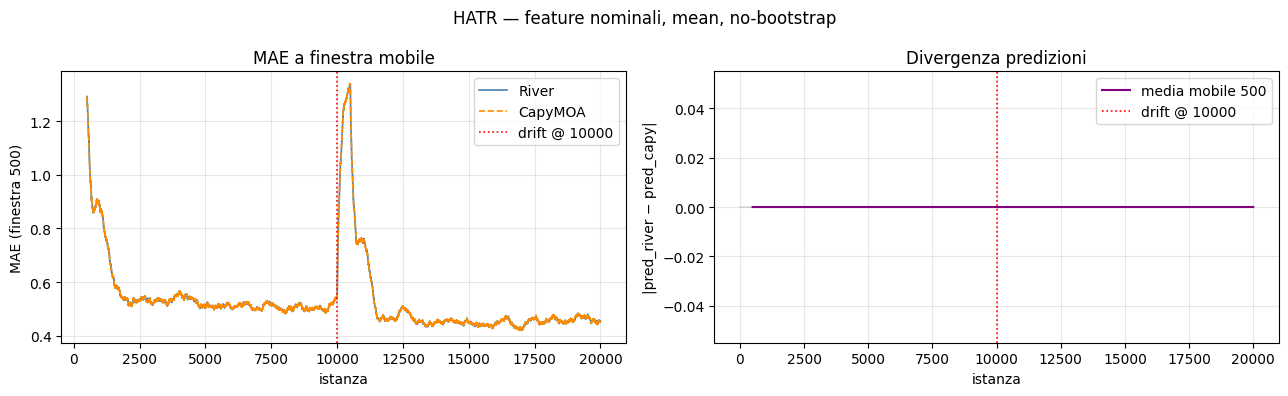

In [8]:
W = 500
x_axis = np.arange(W - 1, N)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# --- MAE a finestra ---
ax = axes[0]
ax.plot(x_axis, win_mae(y, river_preds, W), label='River', color='steelblue', lw=1.2)
ax.plot(x_axis, win_mae(y, capy_preds,  W), label='CapyMOA', color='darkorange',
        lw=1.2, linestyle='--')
ax.axvline(DRIFT_AT, color='red', lw=1.2, linestyle=':', label=f'drift @ {DRIFT_AT}')
ax.set_xlabel('istanza')
ax.set_ylabel(f'MAE (finestra {W})')
ax.set_title('MAE a finestra mobile')
ax.legend()
ax.grid(alpha=0.3)

# --- Differenza assoluta predizioni ---
ax = axes[1]
diff = np.abs(river_preds - capy_preds)
ax.plot(np.arange(N), diff, color='gray', lw=0.5, alpha=0.6)
ax.plot(x_axis, np.convolve(diff, np.ones(W) / W, mode='valid'),
        color='purple', lw=1.5, label=f'media mobile {W}')
ax.axvline(DRIFT_AT, color='red', lw=1.2, linestyle=':', label=f'drift @ {DRIFT_AT}')
ax.set_xlabel('istanza')
ax.set_ylabel('|pred_river − pred_capy|')
ax.set_title('Divergenza predizioni')
ax.legend()
ax.grid(alpha=0.3)

plt.suptitle('HATR — feature nominali, mean, no-bootstrap', fontsize=12)
plt.tight_layout()
plt.show()

## Consistenza River vs CapyMOA

In [9]:
diff = np.abs(river_preds - capy_preds)
corr = float(np.corrcoef(river_preds[SKIP:], capy_preds[SKIP:])[0, 1])

print(f"Correlazione predizioni (i>{SKIP}): {corr:.6f}")
print(f"Max |Δpred|:                    {diff.max():.6f}")
print(f"Mean |Δpred|:                   {diff.mean():.6f}")
print(f"Frac |Δpred| < 1e-6:            {np.mean(diff < 1e-6):.4f}")
print()
print(f"MAE River:   {mae(y[SKIP:], river_preds[SKIP:]):.6f}")
print(f"MAE CapyMOA: {mae(y[SKIP:], capy_preds[SKIP:]):.6f}")
print(f"|ΔMAE|:      {abs(mae(y[SKIP:], river_preds[SKIP:]) - mae(y[SKIP:], capy_preds[SKIP:])):.6f}")

Correlazione predizioni (i>50): 1.000000
Max |Δpred|:                    0.000000
Mean |Δpred|:                   0.000000
Frac |Δpred| < 1e-6:            1.0000

MAE River:   0.544023
MAE CapyMOA: 0.544023
|ΔMAE|:      0.000000


## Discussione

**Dataset.** Stream sintetico con 3 feature nominali (`season`, `weather`, `time_of_day`) e 2 numeriche, con concept drift abrupt a istanza 10 000: prima del drift il consumo energetico dipende da `season` e `temperature`, dopo dal `time_of_day` e `humidity`.

**Encoding delle feature nominali.**
- River riceve i valori come stringhe nel dizionario; il suo HATR effettua split per uguaglianza di valore (`x == val`), esattamente come il Hoeffding tree originale.
- CapyMOA/MOA riceve gli indici interi (codifica ARFF standard: `spring=0`, `summer=1`, …); internamente MOA gestisce split nominali tramite indice.

**Consistenza.**
Con `bootstrap_sampling=False` e `leaf_prediction='mean'`, le due implementazioni sono deterministiche. Se le predizioni coincidono (`|Δpred| ≈ 0`), confermano che la logica di split nominale è equivalente; eventuali divergenze indicano differenze nella codifica o nelle euristiche di split.

**Adattamento al drift.**
Il picco di MAE nella finestra mobile intorno a istanza 10 000 misura la latenza di adattamento dopo il cambio di concetto. ADWIN rileva la deriva e forza il ricalcolo dei nodi foglia; l'ampiezza del picco dipende da `drift_window_threshold` e `switch_significance`.